In [2]:
!pip install skyfield pandas matplotlib pytz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 19.8 MB/s eta 0:00:00


In [3]:
from skyfield.api import load, Topos
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

In [4]:
# Observer location
OBSERVER_NAME = "Cairo, Egypt"
LATITUDE = 30.0444
LONGITUDE = 31.2357

# Prediction date (UTC date)
YEAR = 2026
MONTH = 4
DAY = 17

# Tracking settings
MIN_TRACKING_ALTITUDE = 10
TIME_STEP_MINUTES = 1

# Satellite data source settings
USE_STATIONS_GROUP = True
USE_VISUAL_GROUP = True
MAX_VISUAL_SATELLITES = 20

# Motor step conversion settings
AZIMUTH_DEG_PER_STEP = 1.8
ALTITUDE_DEG_PER_STEP = 1.8

In [5]:
ts = load.timescale()
observer = Topos(latitude_degrees=LATITUDE, longitude_degrees=LONGITUDE)

egypt_tz = pytz.timezone("Africa/Cairo")

In [6]:
def utc_to_egypt(utc_iso_string):
    dt_utc = datetime.fromisoformat(utc_iso_string.replace("Z", "+00:00"))
    dt_local = dt_utc.astimezone(egypt_tz)
    return dt_local.strftime("%Y-%m-%d %H:%M:%S %Z")

def compute_satellite_day_data(satellite, observer, times):
    records = []

    for t in times:
        difference = satellite - observer
        topocentric = difference.at(t)
        alt, az, distance = topocentric.altaz()

        records.append({
            "time_utc": t.utc_iso(),
            "altitude_deg": alt.degrees,
            "azimuth_deg": az.degrees,
            "distance_km": distance.km
        })

    return pd.DataFrame(records)

def extract_passes(df, satellite_name, min_tracking_altitude=10):
    temp = df.copy()
    temp["visible"] = temp["altitude_deg"] > 0
    temp["pass_group"] = (temp["visible"] != temp["visible"].shift()).cumsum()

    passes = []

    for _, group in temp.groupby("pass_group"):
        if group["visible"].iloc[0]:
            pass_start_utc = group.iloc[0]["time_utc"]
            pass_end_utc = group.iloc[-1]["time_utc"]
            duration_minutes = len(group)
            max_altitude_deg = group["altitude_deg"].max()
            avg_altitude_deg = group["altitude_deg"].mean()

            idx_max = group["altitude_deg"].idxmax()
            peak_time_utc = temp.loc[idx_max, "time_utc"]

            useful_points = int((group["altitude_deg"] >= min_tracking_altitude).sum())

            tracking_score = (
                0.4 * max_altitude_deg +
                0.2 * duration_minutes +
                0.2 * avg_altitude_deg +
                0.2 * useful_points
            )

            passes.append({
                "satellite_name": satellite_name,
                "pass_start_utc": pass_start_utc,
                "pass_end_utc": pass_end_utc,
                "pass_start_egypt": utc_to_egypt(pass_start_utc),
                "pass_end_egypt": utc_to_egypt(pass_end_utc),
                "peak_time_utc": peak_time_utc,
                "peak_time_egypt": utc_to_egypt(peak_time_utc),
                "duration_minutes": duration_minutes,
                "max_altitude_deg": max_altitude_deg,
                "avg_altitude_deg": avg_altitude_deg,
                "useful_tracking_points": useful_points,
                "practical_tracking_pass": max_altitude_deg >= min_tracking_altitude,
                "tracking_score": tracking_score
            })

    return pd.DataFrame(passes)

def build_tracking_table(df, pass_start_utc, pass_end_utc):
    tracking_df = df[
        (df["time_utc"] >= pass_start_utc) &
        (df["time_utc"] <= pass_end_utc)
    ].copy()

    tracking_df = tracking_df[[
        "time_utc", "azimuth_deg", "altitude_deg", "distance_km"
    ]].copy()

    tracking_df["time_egypt"] = tracking_df["time_utc"].apply(utc_to_egypt)
    tracking_df["delta_azimuth_deg"] = tracking_df["azimuth_deg"].diff().fillna(0)
    tracking_df["delta_altitude_deg"] = tracking_df["altitude_deg"].diff().fillna(0)

    return tracking_df

def convert_degrees_to_steps(tracking_df, azimuth_deg_per_step=1.8, altitude_deg_per_step=1.8):
    commands_df = tracking_df[[
        "time_utc", "time_egypt", "delta_azimuth_deg", "delta_altitude_deg"
    ]].copy()

    commands_df["azimuth_steps"] = (commands_df["delta_azimuth_deg"] / azimuth_deg_per_step).round().astype(int)
    commands_df["altitude_steps"] = (commands_df["delta_altitude_deg"] / altitude_deg_per_step).round().astype(int)

    return commands_df

In [7]:
satellites = []

if USE_STATIONS_GROUP:
    stations_url = 'https://celestrak.org/NORAD/elements/gp.php?GROUP=stations&FORMAT=tle'
    stations_sats = load.tle_file(stations_url)
    satellites.extend(stations_sats)

if USE_VISUAL_GROUP:
    visual_url = 'https://celestrak.org/NORAD/elements/gp.php?GROUP=visual&FORMAT=tle'
    visual_sats = load.tle_file(visual_url)
    satellites.extend(visual_sats[:MAX_VISUAL_SATELLITES])

unique_sats = {}
for sat in satellites:
    unique_sats[sat.name] = sat

satellites = list(unique_sats.values())

print(f"Loaded {len(satellites)} unique satellites.")
print([sat.name for sat in satellites[:10]])

[#################################] 100% gp.php


Loaded 31 unique satellites.
['ISS (ZARYA)', 'POISK', 'CSS (TIANHE)', 'ISS (NAUKA)', 'FREGAT DEB', 'CSS (WENTIAN)', 'CSS (MENGTIAN)', 'TIANZHOU-9', 'PROGRESS-MS 32', 'YOTSUBA-KULOVER']


In [8]:
minutes = list(range(0, 24 * 60, TIME_STEP_MINUTES))
times = ts.utc(YEAR, MONTH, DAY, 0, minutes)

print("Number of time steps:", len(minutes))

Number of time steps: 1440


In [9]:
all_passes_list = []
daily_data_by_satellite = {}
best_pass_per_satellite = []

for satellite in satellites:
    try:
        day_df = compute_satellite_day_data(satellite, observer, times)
        daily_data_by_satellite[satellite.name] = day_df

        passes_df = extract_passes(
            day_df,
            satellite_name=satellite.name,
            min_tracking_altitude=MIN_TRACKING_ALTITUDE
        )

        if len(passes_df) > 0:
            all_passes_list.append(passes_df)

            practical_passes = passes_df[passes_df["practical_tracking_pass"] == True].copy()

            if len(practical_passes) > 0:
                best_pass = practical_passes.sort_values(
                    by=["tracking_score", "max_altitude_deg", "duration_minutes"],
                    ascending=[False, False, False]
                ).iloc[0]
            else:
                best_pass = passes_df.sort_values(
                    by=["tracking_score", "max_altitude_deg", "duration_minutes"],
                    ascending=[False, False, False]
                ).iloc[0]

            best_pass_per_satellite.append(best_pass.to_dict())

    except Exception as e:
        print(f"Error processing satellite {satellite.name}: {e}")

In [10]:
if len(all_passes_list) > 0:
    all_passes_df = pd.concat(all_passes_list, ignore_index=True)
else:
    all_passes_df = pd.DataFrame()

best_pass_per_satellite_df = pd.DataFrame(best_pass_per_satellite)

print("All passes shape:", all_passes_df.shape)
print("Best pass per satellite shape:", best_pass_per_satellite_df.shape)

best_pass_per_satellite_df.head()

All passes shape: (198, 13)
Best pass per satellite shape: (31, 13)


,satellite_name,pass_start_utc,pass_end_utc,pass_start_egypt,pass_end_egypt,peak_time_utc,peak_time_egypt,duration_minutes,max_altitude_deg,avg_altitude_deg,useful_tracking_points,practical_tracking_pass,tracking_score
0,ISS (ZARYA),2026-04-17T10:44:00Z,2026-04-17T10:54:00Z,2026-04-17 12:44:00 EET,2026-04-17 12:54:00 EET,2026-04-17T10:49:00Z,2026-04-17 12:49:00 EET,11,42.684783,17.288093,6,True,23.931532
1,POISK,2026-04-17T10:44:00Z,2026-04-17T10:54:00Z,2026-04-17 12:44:00 EET,2026-04-17 12:54:00 EET,2026-04-17T10:49:00Z,2026-04-17 12:49:00 EET,11,42.684783,17.288093,6,True,23.931532
2,CSS (TIANHE),2026-04-17T14:49:00Z,2026-04-17T14:58:00Z,2026-04-17 16:49:00 EET,2026-04-17 16:58:00 EET,2026-04-17T14:53:00Z,2026-04-17 16:53:00 EET,10,35.736203,15.947432,6,True,20.683968
3,ISS (NAUKA),2026-04-17T10:44:00Z,2026-04-17T10:54:00Z,2026-04-17 12:44:00 EET,2026-04-17 12:54:00 EET,2026-04-17T10:49:00Z,2026-04-17 12:49:00 EET,11,42.684783,17.288093,6,True,23.931532
4,FREGAT DEB,2026-04-17T21:56:00Z,2026-04-17T22:22:00Z,2026-04-17 23:56:00 EET,2026-04-18 00:22:00 EET,2026-04-17T22:11:00Z,2026-04-18 00:11:00 EET,27,84.271114,32.244036,21,True,49.757253


In [11]:
if len(best_pass_per_satellite_df) == 0:
    raise ValueError("No visible passes found for any satellite on this day.")

practical_best_df = best_pass_per_satellite_df[
    best_pass_per_satellite_df["practical_tracking_pass"] == True
].copy()

if len(practical_best_df) > 0:
    overall_best = practical_best_df.sort_values(
        by=["tracking_score", "max_altitude_deg", "duration_minutes"],
        ascending=[False, False, False]
    ).iloc[0]
else:
    overall_best = best_pass_per_satellite_df.sort_values(
        by=["tracking_score", "max_altitude_deg", "duration_minutes"],
        ascending=[False, False, False]
    ).iloc[0]

best_satellite_name = overall_best["satellite_name"]
best_pass_start_utc = overall_best["pass_start_utc"]
best_pass_end_utc = overall_best["pass_end_utc"]

print("Best Satellite:", best_satellite_name)
print("Pass Start Egypt:", overall_best["pass_start_egypt"])
print("Pass End Egypt:", overall_best["pass_end_egypt"])
print("Peak Time Egypt:", overall_best["peak_time_egypt"])
print("Duration (minutes):", overall_best["duration_minutes"])
print("Max Altitude (deg):", round(overall_best["max_altitude_deg"], 2))
print("Tracking Score:", round(overall_best["tracking_score"], 2))

Best Satellite: FREGAT DEB
Pass Start Egypt: 2026-04-17 23:56:00 EET
Pass End Egypt: 2026-04-18 00:22:00 EET
Peak Time Egypt: 2026-04-18 00:11:00 EET
Duration (minutes): 27
Max Altitude (deg): 84.27
Tracking Score: 49.76


In [12]:
best_day_df = daily_data_by_satellite[best_satellite_name]

best_tracking_df = build_tracking_table(
    best_day_df,
    best_pass_start_utc,
    best_pass_end_utc
)

best_tracking_filtered_df = best_tracking_df[
    best_tracking_df["altitude_deg"] >= MIN_TRACKING_ALTITUDE
].copy()

if len(best_tracking_filtered_df) == 0:
    best_tracking_filtered_df = best_tracking_df.copy()

best_tracking_filtered_df.head()

,time_utc,azimuth_deg,altitude_deg,distance_km,time_egypt,delta_azimuth_deg,delta_altitude_deg
1320,2026-04-17T22:00:00Z,221.511325,11.829693,4364.879713,2026-04-18 00:00:00 EET,0.088243,2.959079
1321,2026-04-17T22:01:00Z,221.607364,15.028424,4070.925659,2026-04-18 00:01:00 EET,0.096039,3.198730
1322,2026-04-17T22:02:00Z,221.711747,18.522334,3778.239455,2026-04-18 00:02:00 EET,0.104383,3.493910
1323,2026-04-17T22:03:00Z,221.825335,22.383748,3488.182894,2026-04-18 00:03:00 EET,0.113588,3.861414
1324,2026-04-17T22:04:00Z,221.949499,26.707534,3202.578151,2026-04-18 00:04:00 EET,0.124164,4.323786


In [13]:
tracker_commands_df = convert_degrees_to_steps(
    best_tracking_filtered_df,
    azimuth_deg_per_step=AZIMUTH_DEG_PER_STEP,
    altitude_deg_per_step=ALTITUDE_DEG_PER_STEP
)

tracker_commands_df.head()

,time_utc,time_egypt,delta_azimuth_deg,delta_altitude_deg,azimuth_steps,altitude_steps
1320,2026-04-17T22:00:00Z,2026-04-18 00:00:00 EET,0.088243,2.959079,0,2
1321,2026-04-17T22:01:00Z,2026-04-18 00:01:00 EET,0.096039,3.198730,0,2
1322,2026-04-17T22:02:00Z,2026-04-18 00:02:00 EET,0.104383,3.493910,0,2
1323,2026-04-17T22:03:00Z,2026-04-18 00:03:00 EET,0.113588,3.861414,0,2
1324,2026-04-17T22:04:00Z,2026-04-18 00:04:00 EET,0.124164,4.323786,0,2


In [14]:
all_passes_df.to_csv("all_satellite_passes_full_day.csv", index=False)
best_pass_per_satellite_df.to_csv("best_pass_per_satellite.csv", index=False)
best_tracking_df.to_csv("overall_best_tracking_table.csv", index=False)
best_tracking_filtered_df.to_csv("overall_best_tracking_filtered_table.csv", index=False)
tracker_commands_df.to_csv("tracker_motor_commands.csv", index=False)

summary = {
    "Observer": OBSERVER_NAME,
    "Latitude": LATITUDE,
    "Longitude": LONGITUDE,
    "Prediction Date UTC": f"{YEAR}-{MONTH:02d}-{DAY:02d}",
    "Satellites Evaluated": len(satellites),
    "Best Satellite": best_satellite_name,
    "Best Pass Start Egypt": overall_best["pass_start_egypt"],
    "Best Pass End Egypt": overall_best["pass_end_egypt"],
    "Peak Time Egypt": overall_best["peak_time_egypt"],
    "Best Pass Duration (min)": int(overall_best["duration_minutes"]),
    "Best Pass Max Altitude (deg)": round(overall_best["max_altitude_deg"], 2),
    "Best Pass Avg Altitude (deg)": round(overall_best["avg_altitude_deg"], 2),
    "Useful Tracking Points": int(overall_best["useful_tracking_points"]),
    "Tracking Score": round(overall_best["tracking_score"], 2)
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv("project_summary.csv", index=False)

print("Files saved successfully.")

Files saved successfully.


In [15]:
summary_df

,Observer,Latitude,Longitude,Prediction Date UTC,Satellites Evaluated,Best Satellite,Best Pass Start Egypt,Best Pass End Egypt,Peak Time Egypt,Best Pass Duration (min),Best Pass Max Altitude (deg),Best Pass Avg Altitude (deg),Useful Tracking Points,Tracking Score
0,"Cairo, Egypt",30.0444,31.2357,2026-04-17,31,FREGAT DEB,2026-04-17 23:56:00 EET,2026-04-18 00:22:00 EET,2026-04-18 00:11:00 EET,27,84.27,32.24,21,49.76


In [16]:
best_pass_per_satellite_df.head(10)

,satellite_name,pass_start_utc,pass_end_utc,pass_start_egypt,pass_end_egypt,peak_time_utc,peak_time_egypt,duration_minutes,max_altitude_deg,avg_altitude_deg,useful_tracking_points,practical_tracking_pass,tracking_score
0,ISS (ZARYA),2026-04-17T10:44:00Z,2026-04-17T10:54:00Z,2026-04-17 12:44:00 EET,2026-04-17 12:54:00 EET,2026-04-17T10:49:00Z,2026-04-17 12:49:00 EET,11,42.684783,17.288093,6,True,23.931532
1,POISK,2026-04-17T10:44:00Z,2026-04-17T10:54:00Z,2026-04-17 12:44:00 EET,2026-04-17 12:54:00 EET,2026-04-17T10:49:00Z,2026-04-17 12:49:00 EET,11,42.684783,17.288093,6,True,23.931532
2,CSS (TIANHE),2026-04-17T14:49:00Z,2026-04-17T14:58:00Z,2026-04-17 16:49:00 EET,2026-04-17 16:58:00 EET,2026-04-17T14:53:00Z,2026-04-17 16:53:00 EET,10,35.736203,15.947432,6,True,20.683968
3,ISS (NAUKA),2026-04-17T10:44:00Z,2026-04-17T10:54:00Z,2026-04-17 12:44:00 EET,2026-04-17 12:54:00 EET,2026-04-17T10:49:00Z,2026-04-17 12:49:00 EET,11,42.684783,17.288093,6,True,23.931532
4,FREGAT DEB,2026-04-17T21:56:00Z,2026-04-17T22:22:00Z,2026-04-17 23:56:00 EET,2026-04-18 00:22:00 EET,2026-04-17T22:11:00Z,2026-04-18 00:11:00 EET,27,84.271114,32.244036,21,True,49.757253
5,CSS (WENTIAN),2026-04-17T14:49:00Z,2026-04-17T14:58:00Z,2026-04-17 16:49:00 EET,2026-04-17 16:58:00 EET,2026-04-17T14:53:00Z,2026-04-17 16:53:00 EET,10,35.736203,15.947432,6,True,20.683968
6,CSS (MENGTIAN),2026-04-17T14:49:00Z,2026-04-17T14:58:00Z,2026-04-17 16:49:00 EET,2026-04-17 16:58:00 EET,2026-04-17T14:53:00Z,2026-04-17 16:53:00 EET,10,35.736203,15.947432,6,True,20.683968
7,TIANZHOU-9,2026-04-17T14:49:00Z,2026-04-17T14:58:00Z,2026-04-17 16:49:00 EET,2026-04-17 16:58:00 EET,2026-04-17T14:53:00Z,2026-04-17 16:53:00 EET,10,35.736203,15.947432,6,True,20.683968
8,PROGRESS-MS 32,2026-04-17T10:44:00Z,2026-04-17T10:54:00Z,2026-04-17 12:44:00 EET,2026-04-17 12:54:00 EET,2026-04-17T10:49:00Z,2026-04-17 12:49:00 EET,11,42.684783,17.288093,6,True,23.931532
9,YOTSUBA-KULOVER,2026-04-17T08:39:00Z,2026-04-17T08:44:00Z,2026-04-17 10:39:00 EET,2026-04-17 10:44:00 EET,2026-04-17T08:41:00Z,2026-04-17 10:41:00 EET,6,31.631871,14.026930,3,True,17.258135


In [17]:
best_tracking_filtered_df.head(10)

,time_utc,azimuth_deg,altitude_deg,distance_km,time_egypt,delta_azimuth_deg,delta_altitude_deg
1320,2026-04-17T22:00:00Z,221.511325,11.829693,4364.879713,2026-04-18 00:00:00 EET,0.088243,2.959079
1321,2026-04-17T22:01:00Z,221.607364,15.028424,4070.925659,2026-04-18 00:01:00 EET,0.096039,3.198730
1322,2026-04-17T22:02:00Z,221.711747,18.522334,3778.239455,2026-04-18 00:02:00 EET,0.104383,3.493910
1323,2026-04-17T22:03:00Z,221.825335,22.383748,3488.182894,2026-04-18 00:03:00 EET,0.113588,3.861414
1324,2026-04-17T22:04:00Z,221.949499,26.707534,3202.578151,2026-04-18 00:04:00 EET,0.124164,4.323786
1325,2026-04-17T22:05:00Z,222.086514,31.618404,2923.908903,2026-04-18 00:05:00 EET,0.137014,4.910870
1326,2026-04-17T22:06:00Z,222.240371,37.279110,2655.615205,2026-04-18 00:06:00 EET,0.153857,5.660706
1327,2026-04-17T22:07:00Z,222.418711,43.896595,2402.511916,2026-04-18 00:07:00 EET,0.178341,6.617485
1328,2026-04-17T22:08:00Z,222.638119,51.717513,2171.332826,2026-04-18 00:08:00 EET,0.219408,7.820919
1329,2026-04-17T22:09:00Z,222.942473,60.993392,1971.288066,2026-04-18 00:09:00 EET,0.304354,9.275879


In [18]:
tracker_commands_df.head(10)

,time_utc,time_egypt,delta_azimuth_deg,delta_altitude_deg,azimuth_steps,altitude_steps
1320,2026-04-17T22:00:00Z,2026-04-18 00:00:00 EET,0.088243,2.959079,0,2
1321,2026-04-17T22:01:00Z,2026-04-18 00:01:00 EET,0.096039,3.198730,0,2
1322,2026-04-17T22:02:00Z,2026-04-18 00:02:00 EET,0.104383,3.493910,0,2
1323,2026-04-17T22:03:00Z,2026-04-18 00:03:00 EET,0.113588,3.861414,0,2
1324,2026-04-17T22:04:00Z,2026-04-18 00:04:00 EET,0.124164,4.323786,0,2
1325,2026-04-17T22:05:00Z,2026-04-18 00:05:00 EET,0.137014,4.910870,0,3
1326,2026-04-17T22:06:00Z,2026-04-18 00:06:00 EET,0.153857,5.660706,0,3
1327,2026-04-17T22:07:00Z,2026-04-18 00:07:00 EET,0.178341,6.617485,0,4
1328,2026-04-17T22:08:00Z,2026-04-18 00:08:00 EET,0.219408,7.820919,0,4
1329,2026-04-17T22:09:00Z,2026-04-18 00:09:00 EET,0.304354,9.275879,0,5


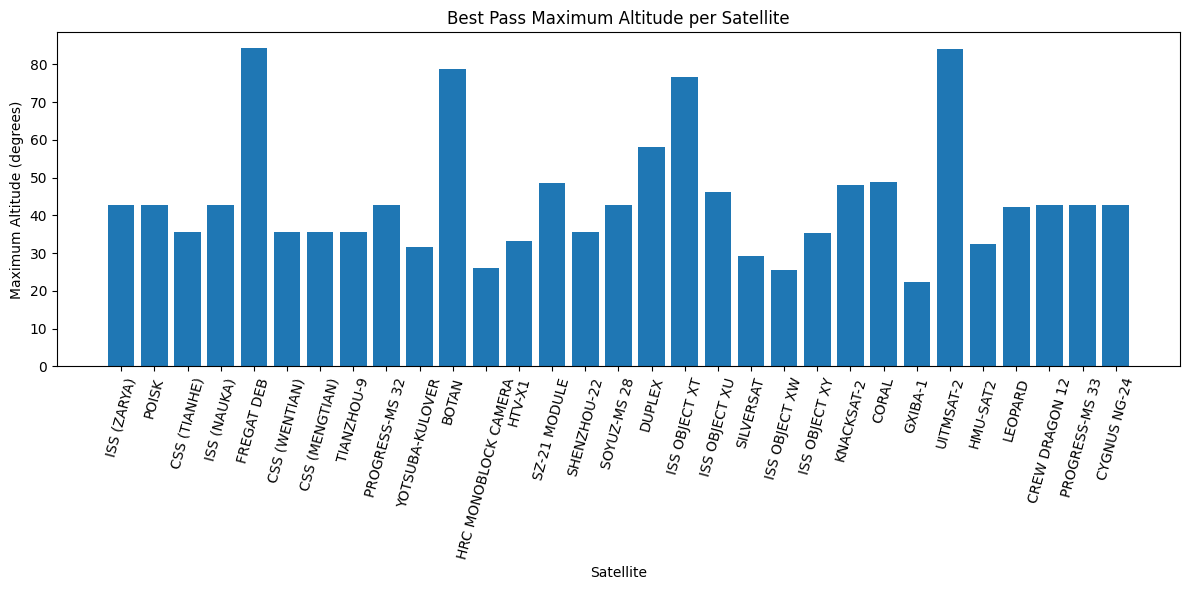

In [19]:
plt.figure(figsize=(12, 6))
plt.bar(best_pass_per_satellite_df["satellite_name"], best_pass_per_satellite_df["max_altitude_deg"])
plt.title("Best Pass Maximum Altitude per Satellite")
plt.xlabel("Satellite")
plt.ylabel("Maximum Altitude (degrees)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

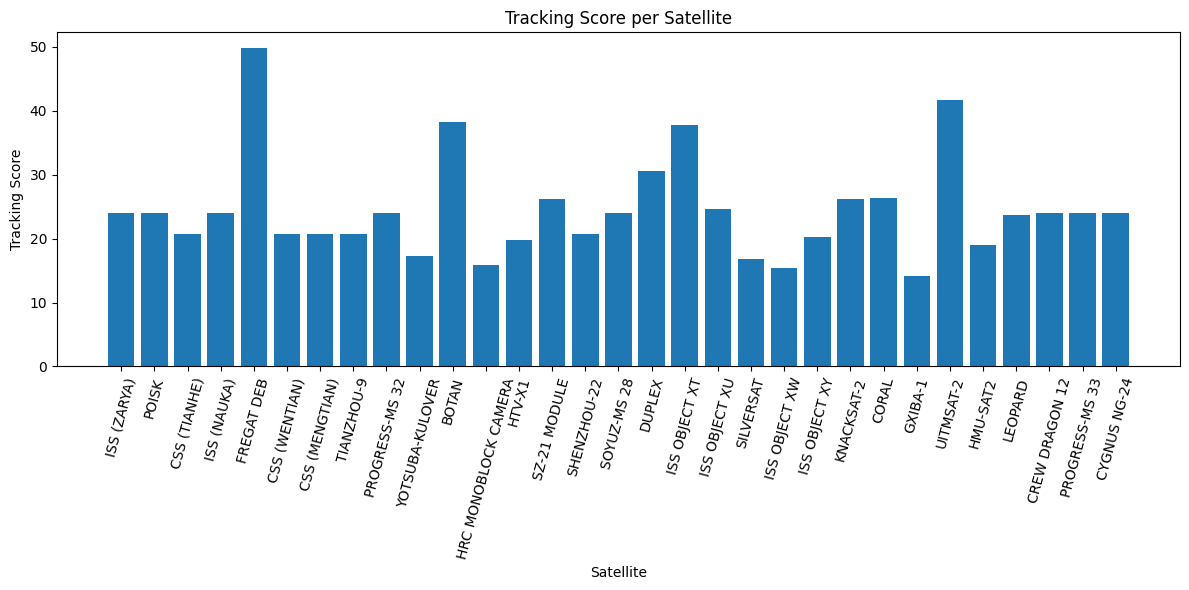

In [20]:
plt.figure(figsize=(12, 6))
plt.bar(best_pass_per_satellite_df["satellite_name"], best_pass_per_satellite_df["tracking_score"])
plt.title("Tracking Score per Satellite")
plt.xlabel("Satellite")
plt.ylabel("Tracking Score")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

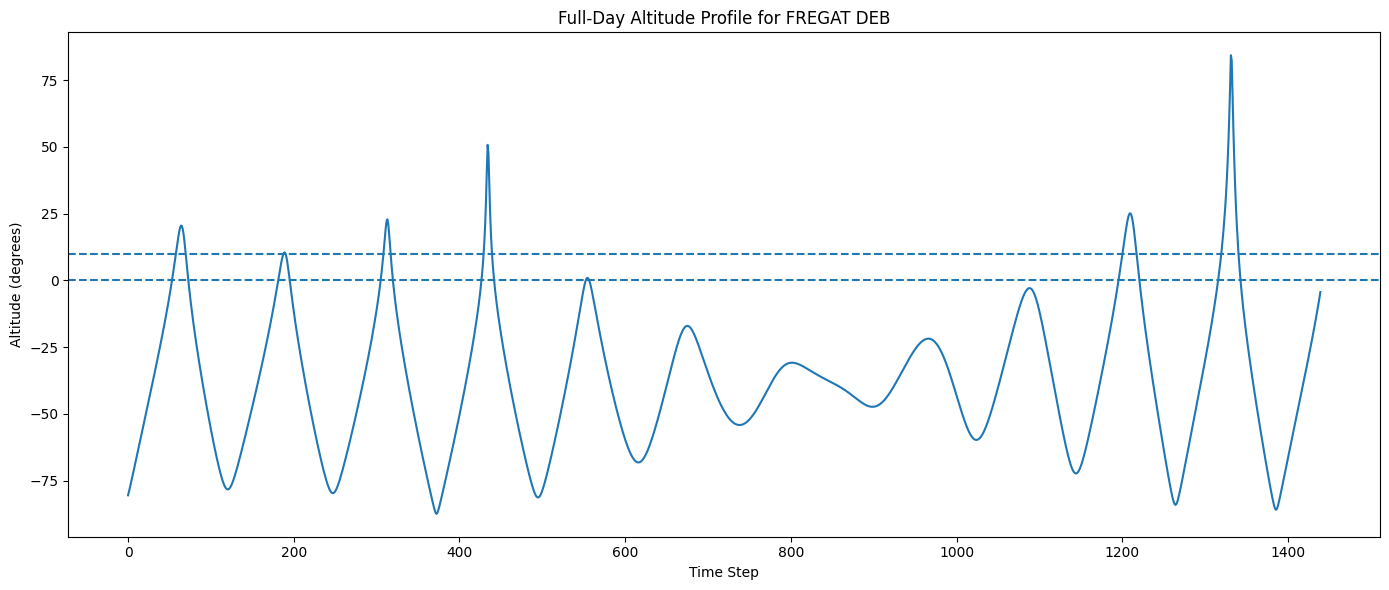

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(best_day_df["altitude_deg"])
plt.axhline(y=0, linestyle='--')
plt.axhline(y=MIN_TRACKING_ALTITUDE, linestyle='--')
plt.title(f"Full-Day Altitude Profile for {best_satellite_name}")
plt.xlabel("Time Step")
plt.ylabel("Altitude (degrees)")
plt.tight_layout()
plt.show()

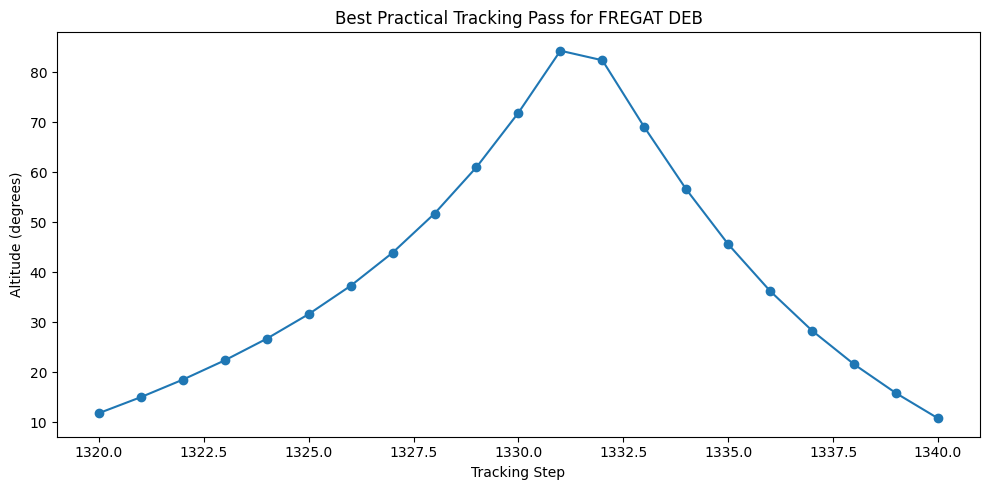

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(best_tracking_filtered_df["altitude_deg"], marker='o')
plt.title(f"Best Practical Tracking Pass for {best_satellite_name}")
plt.xlabel("Tracking Step")
plt.ylabel("Altitude (degrees)")
plt.tight_layout()
plt.show()

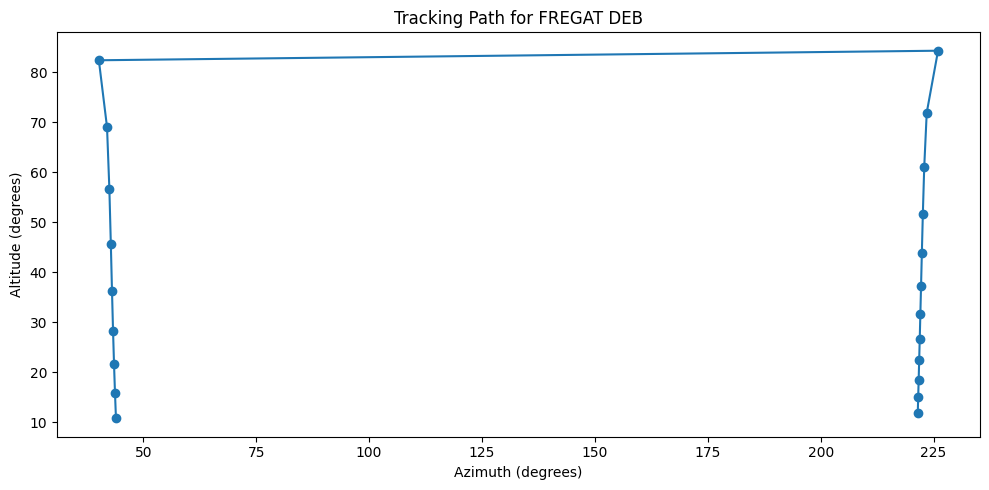

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(best_tracking_filtered_df["azimuth_deg"], best_tracking_filtered_df["altitude_deg"], marker='o')
plt.title(f"Tracking Path for {best_satellite_name}")
plt.xlabel("Azimuth (degrees)")
plt.ylabel("Altitude (degrees)")
plt.tight_layout()
plt.show()